# MIDI-to-audio generation 


In [1]:
import gin

gin.enter_interactive_mode()

from IPython.display import display, Audio
import torch
import numpy as np
import librosa
import matplotlib.pyplot as plt
import sys
import os

sys.path.append('..')
torch.set_grad_enabled(False)

## Model Loading

Model can be loaded from a training checkpoint (.pt file stored by default in ./after_runs/#model_name), or from an already exported .ts file.

## Load a model from a training Checkpoint

In [2]:
model_path = ""
step = None  # Use None to load the last
autoencoder_path = ""
device = "cuda:0"

### Instantiate te model and load the checkpoint

In [3]:
class CheckpointModel(torch.nn.Module):

    def __init__(self, model, emb_model, device=device):
        super().__init__()
        self.model = model
        self.emb_model = emb_model
        self.device = device
        self.to(device)

    def ae_encode(self, x):
        if len(x.shape) > 1:
            x = x.reshape(x.shape[0], 1, -1)  # Flatten the input
        else:
            x = x.reshape(1, 1, -1)

        return self.emb_model.encode(x.to(self.device))

    def ae_decode(self, z):
        return self.emb_model.decode(z.to(self.device)).cpu().squeeze()

    def timbre(self, z):
        z_timbre = self.model.encoder(z.to(self.device))
        if self.model.post_encoder is not None:
            z_timbre = self.model.post_encoder(z_timbre)
        return z_timbre

    def structure(self, pr):
        return self.model.encoder_time(pr.to(self.device))

    def sample(self, noise, z_structure, z_timbre, guidance_structure,
               nb_steps):

        zout = self.model.sample(noise.to(self.device),
                                 time_cond=z_structure.to(self.device),
                                 cond=z_timbre.to(self.device),
                                 nb_steps=nb_steps,
                                 guidance_structure=guidance_structure)
        return zout

In [10]:
from after.diffusion import RectifiedFlow

if step is None:
    files = os.listdir(model_path)
    files = [f for f in files if f.startswith("checkpoint")]
    steps = [f.split("_")[-2].replace("checkpoint", "") for f in files]
    step = max([int(s) for s in steps])
    checkpoint_file = "checkpoint" + str(step) + "_EMA.pt"
else:
    checkpoint_file = "checkpoint" + str(step) + "_EMA.pt"

checkpoint_file = os.path.join(model_path, checkpoint_file)
config = os.path.join(model_path, "config.gin")

# Parse config
gin.parse_config_file(config)
SR = gin.query_parameter("%SR")
n_signal = gin.query_parameter("%N_SIGNAL")
latent_size = gin.query_parameter("%IN_SIZE")
# Emb model

# Instantiate model
blender = RectifiedFlow(device=device)

# Load checkpoints
state_dict = torch.load(checkpoint_file, map_location="cpu")["model_state"]
blender.load_state_dict(state_dict, strict=False)

# Emb model
emb_model = torch.jit.load(autoencoder_path).eval()

dummy = torch.randn(1, 1, 8192)  # Dummy input for model initialization
z = emb_model.encode(dummy)

ae_ratio = dummy.shape[-1] // z.shape[-1]

compress_tc = gin.query_parameter("utils.collate_fn.compress_tc")

# Send to device
blender = blender.eval()

model = CheckpointModel(blender, emb_model, device=device)


/data/nils/miniconda3/envs/after/lib/python3.12/site-packages/torch/nn/utils/weight_norm.py:143: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)
/tmp/ipykernel_2296352/986029831.py:26: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_onl

## Load a model from torchscript

In [17]:
ts_path = ""
ts_model = torch.jit.load(ts_path)

SR = 44100
n_signal = ts_model.n_signal
latent_size = ts_model.ae_latents
ae_ratio = ts_model.ae_ratio
compress_tc = ts_model.time_cond_ratio

In [27]:
class TSModel(torch.nn.Module):

    def __init__(self, ts_model, emb_model=None):
        super().__init__()
        self.model = ts_model
        self.emb_model = emb_model
        
    @property
    def device(self):
        return next(self.model.parameters()).device

    def ae_encode(self, x):
        if len(x.shape) > 1:
            x = x.reshape(x.shape[0], 1, -1)  # Flatten the input
        else:
            x = x.reshape(1, 1, -1)

        if self.emb_model is not None:
            return self.emb_model.encode(x)
        return self.model.emb_model_timbre.encode(x)

    def ae_decode(self, z):
        if self.emb_model is not None:
            return self.emb_model.decode(z).squeeze().cpu()
        return self.model.emb_model_timbre.decode(z).squeeze().cpu()

    def timbre(self, z):
        ztimbre = self.model.encoder.forward(z)
        if self.model.post_encoder is not None:
            ztimbre = self.model.post_encoder.forward_stream(ztimbre)
        return ztimbre

    def structure(self, pr):
        try: 
            return self.model.encoder_time.forward_stream(pr.to(self.device))
        except:
            return self.model.encoder_time.forward(pr.to(self.device))
        
    def sample(self, noise, z_structure, z_timbre, guidance_structure,
               nb_steps):

        self.model.set_guidance_structure(guidance_structure)
        self.model.set_nb_steps(nb_steps)
        

        zout = self.model.sample(noise, time_cond=z_structure, cond=z_timbre)

        return zout

In [25]:
model = TSModel(ts_model)

## Audio Samples

You can either load a sample from a prepared lmdb database, or directly from audio files (below). By defaut, audio files are cut to the training length.

#### Load audio from files

In [6]:
audio_path = None
midi_path = ""

offset_midi = 0  #Start moment in the midi file
duration = 5.95  # Duration of the midi chunk and generated audio 
                 #the model will generate audio based on the midi information between offset and offset + duration
                 #Note that some model can't generate more than 64 latent frames at once (5.95 seconds on standard config)

offset_audio = 0  #Start moment in the audio file. Duration will be based on the signal length seen by the model during training

Piano Roll


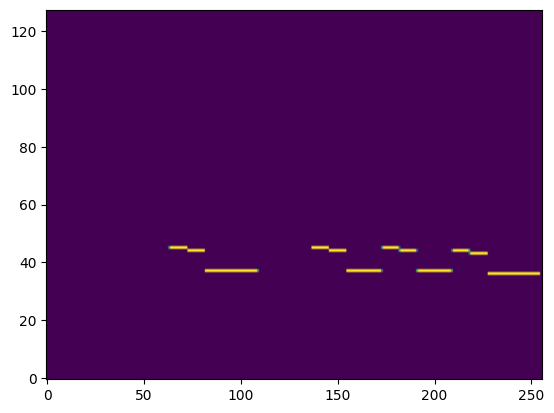

In [11]:
real_duration_samples = int(duration * SR // ae_ratio * ae_ratio)
real_duration_time = real_duration_samples / SR
z_length = real_duration_samples // ae_ratio


if audio_path is not None:
    x1, _ = librosa.load(audio_path,
                        sr=SR,
                        mono=True,
                        offset=offset_audio,
                        duration=10)

    x1 = x1[..., :n_signal * ae_ratio]

    display(Audio(x1, rate=SR))

    x1 = torch.tensor(x1)
    z1 = model.ae_encode(x1)[..., :z_length]

# Get the midi
import pretty_midi

midi = pretty_midi.PrettyMIDI(midi_path)
full_length = z_length * compress_tc
times = np.linspace(0, z_length * ae_ratio / SR, full_length)
pr = midi.get_piano_roll(times=times)
pr = pr / 127.
pr = torch.from_numpy(pr).float().reshape(1, 128, -1)

print("Piano Roll")
plt.imshow(pr[0].cpu().numpy(), aspect="auto", origin="lower")
plt.show()


#### Load audio from the dataset

In [ ]:
from after.dataset import SimpleDataset
from IPython.display import display, Audio

db_path = ""
dataset = SimpleDataset(path=db_path, keys=["z", "midi"])

In [ ]:
d1 = dataset[380]  # Example for timbre
d2 = dataset[40]  # Example for midi

z1 = d1["z"][..., :n_signal]  # guitar
z2 = d2["z"][..., :n_signal]

z1, z2 = torch.tensor(z1).unsqueeze(0), torch.tensor(z2).unsqueeze(0)


def normalize(array):
    return (array - array.min()) / (array.max() - array.min() + 1e-6)

full_length = n_signal * compress_tc
times = np.linspace(0, n_signal * ae_ratio / SR, full_length)
pr = d2["midi"].get_piano_roll(times=times)
pr = pr / 127.
pr = torch.from_numpy(pr).float().reshape(1, 128, -1)

x1, x2 = model.ae_decode(z1), model.ae_decode(z2)

print("Audio for timbre")
display(Audio(x1, rate=SR))
plt.show()

print("Midi Example")
display(Audio(x2, rate=SR))
plt.imshow(pr[0].cpu().numpy(), aspect="auto", origin="lower")
plt.show()

## Generation

In [15]:
nb_steps = 15  #Number of diffusion steps
guidance_structure = 1.0  #Classifier free guidance strength strucutre

In [16]:
# Compute structure representation
z_structure = model.structure(pr)

# Compute timbre representation -  Timbre must be computed on latent codes of length n_signal - by default we use the first n_signal elements

try : 
    z_timbre = model.timbre(z1[..., :n_signal])
except: 
    print("Using fallback fixed timbre representation")
    z_timbre = torch.tensor([[0., 0., 0., 0., 0., 0.]])

# Sample initial noise
noise = torch.randn((1, latent_size, z_structure.shape[-1]), device=model.device)

print("Transfer")

xS = model.sample(
    noise=noise,
    z_structure=z_structure,
    z_timbre=z_timbre,
    nb_steps=nb_steps,
    guidance_structure=guidance_structure,
)

audio_out = model.ae_decode(xS)
display(Audio(audio_out, rate=SR))

Using fallback fixed timbre representation
Transfer
